# Résultats de robustesse sur Xeno-canto

Ce notebook lit les mesures déjà stockées dans la base de données locale, affiche les graphiques et les sauvegarde dans le dossier `data/results/`. Chaque nouvel appel reprend le lot interrompu ou prépare le suivant. Exécuter ce notebook ne lance aucune expérimentation.

## Données et couverture

In [8]:
from IPython.display import Markdown, display

from app.domain.constants import Artifact
from app.domain.settings import ProjectPaths
from app.reporting.service import ExperimentReport, load_report

paths: ProjectPaths = ProjectPaths.from_working_directory()
report: ExperimentReport = load_report(paths)
display(Markdown(report.coverage_text()))

**1,909 audios analysés** · **91 échecs** · **2 lots terminés** · **curseur 2,000**

## Progression du corpus

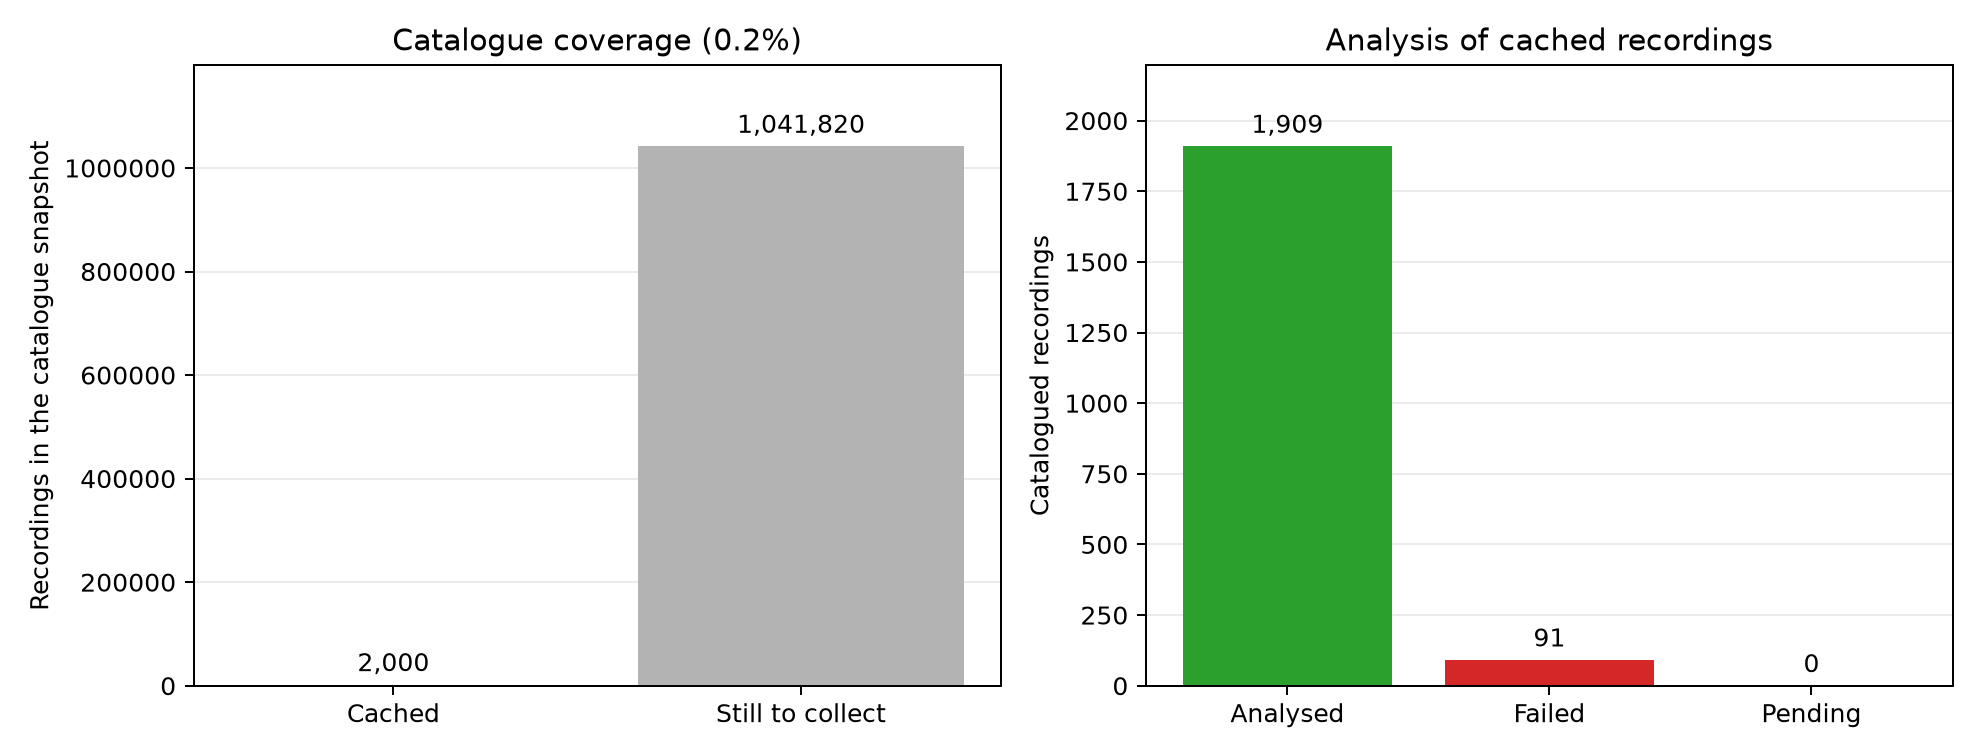

In [9]:
report.show(Artifact.PROGRESS)

## Robustesse au bruit

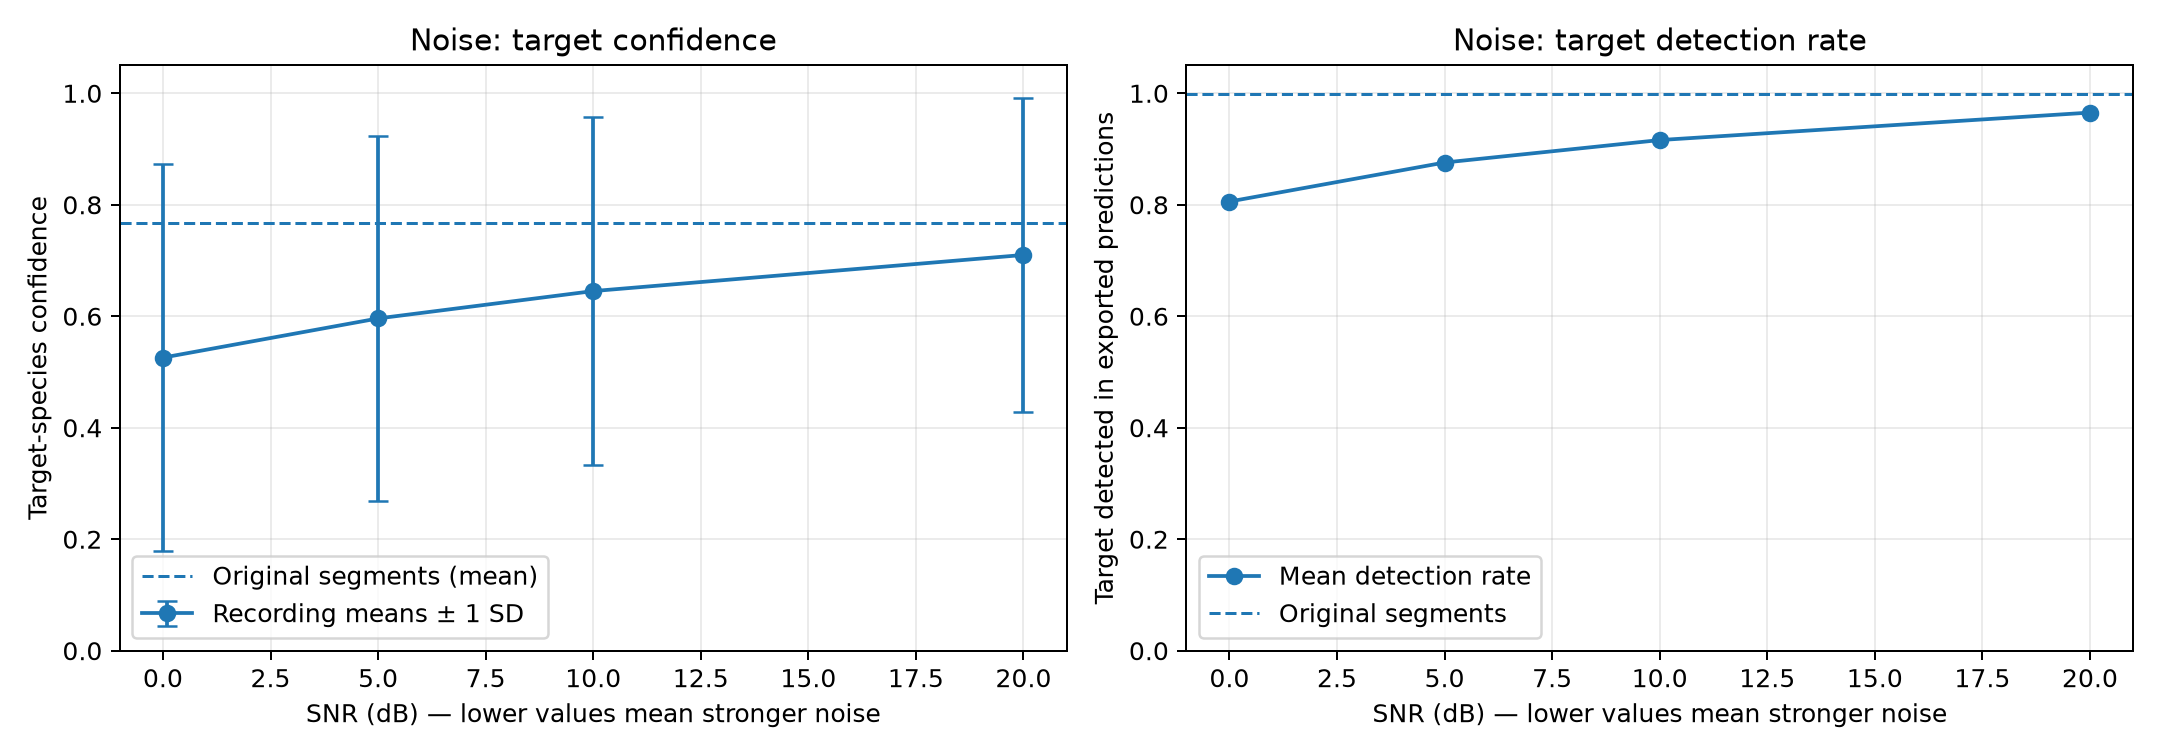

### Observation

Les segments de **1594 enregistrements** ont été testés. La confiance moyenne sans bruit ajouté est **0.768**.

- **20 dB** : confiance moyenne **0.710**, écart-type entre enregistrements **0.281**, cible retrouvée dans **96.5%** des essais.
- **10 dB** : confiance moyenne **0.645**, écart-type entre enregistrements **0.312**, cible retrouvée dans **91.6%** des essais.
- **5 dB** : confiance moyenne **0.596**, écart-type entre enregistrements **0.328**, cible retrouvée dans **87.6%** des essais.
- **0 dB** : confiance moyenne **0.526**, écart-type entre enregistrements **0.347**, cible retrouvée dans **80.6%** des essais.
Les barres montrent un écart-type des moyennes par enregistrement. La variabilité entre réalisations de bruit est exportée séparément dans la table `noise_summaries` du point de reprise SQLite. Une valeur 0 indique une cible absente des prédictions exportées au seuil minimal de 0,10.
**315 enregistrements** sans cible détectée au départ ont été exclus de ce test et sont listés dans la colonne `noise_skip_reason` du catalogue SQLite.

In [10]:
report.show(Artifact.NOISE)

## Chevauchement des vocalisations

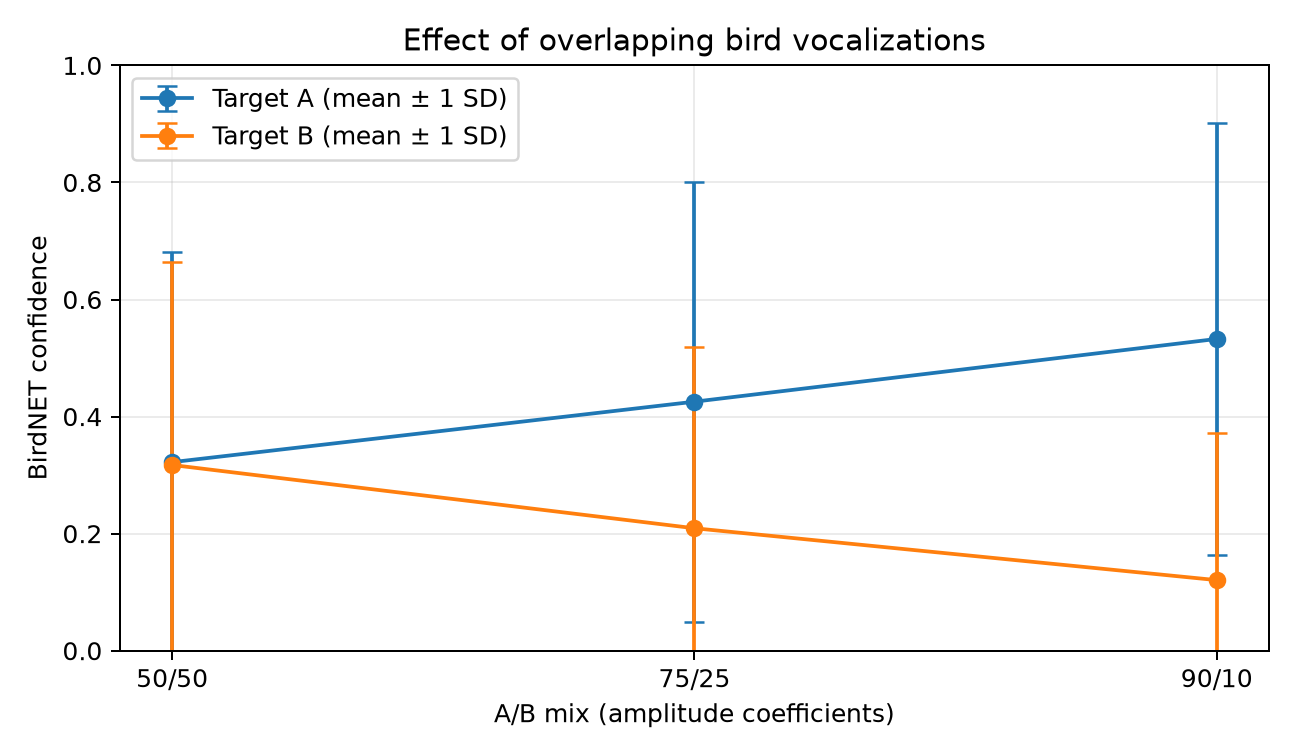

### Observation

Les moyennes portent sur **775 paires** d'enregistrements distincts. Entre les mélanges 50/50 et 90/10, la confiance moyenne de la cible A passe de **0.322** à **0.533**, et celle de la cible B de **0.317** à **0.121**.

A et B désignent les rôles dans chaque paire ; les espèces exactes figurent dans la table `overlap` du point de reprise SQLite. Les barres montrent un écart-type entre paires. Les coefficients portent sur l'amplitude, sans égalisation préalable des niveaux.

In [11]:
report.show(Artifact.OVERLAP)

## Seuil de confiance

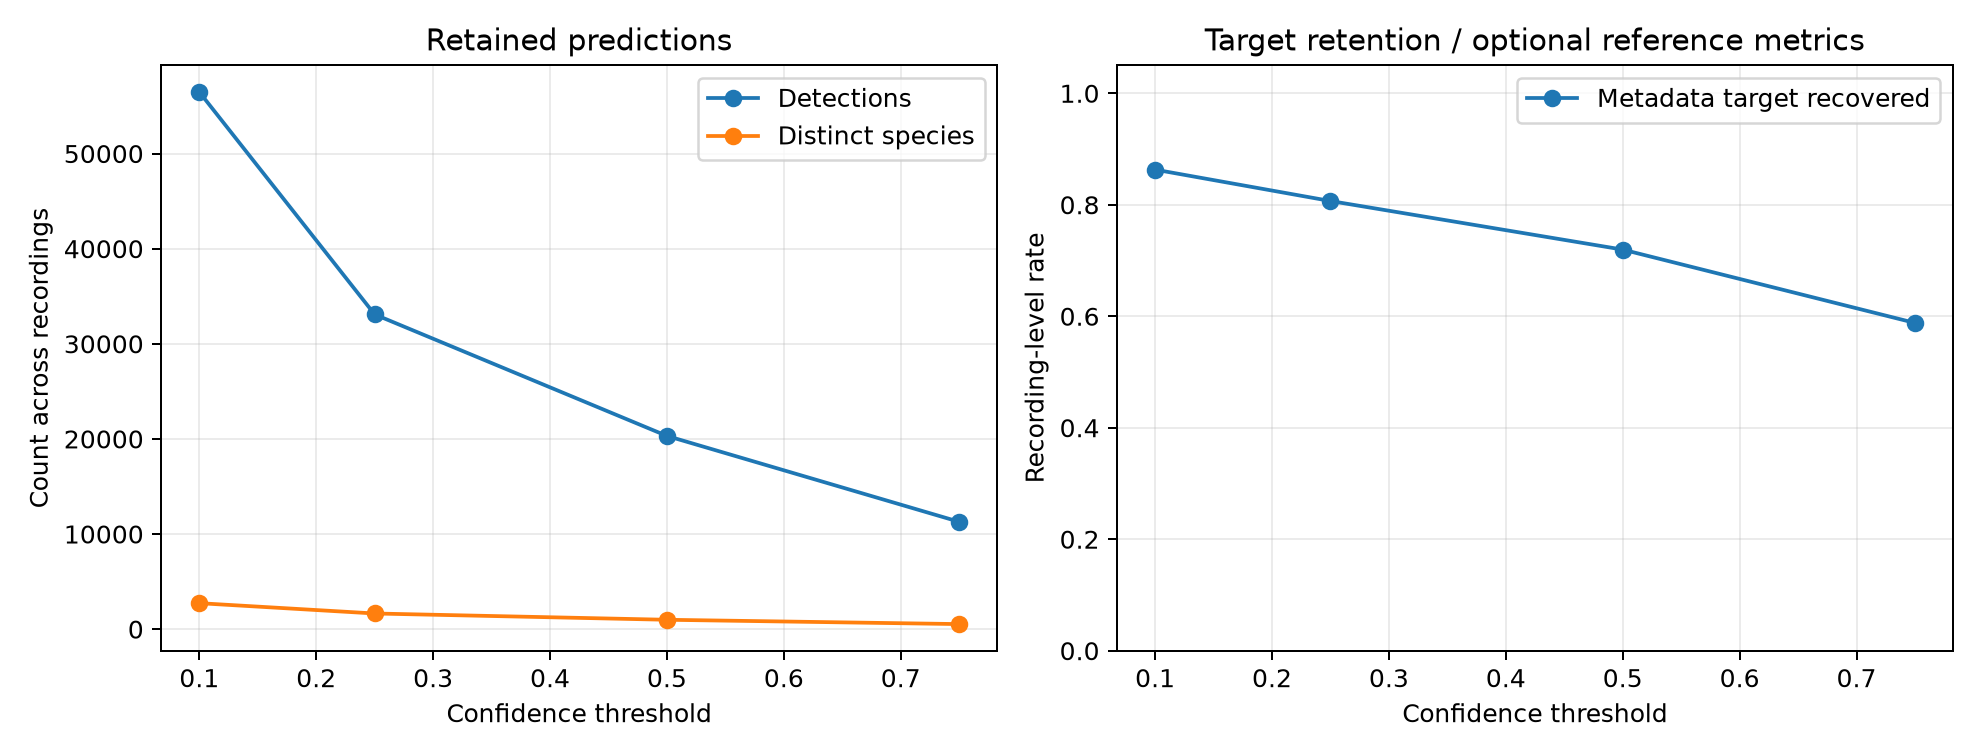

### Observation

Entre les seuils **0.10** et **0.75**, les détections conservées passent de **56475** à **11285**, et les espèces prédites de **2731** à **532**.

L'espèce principale indiquée sur Xeno-canto est retrouvée dans **86.3%** puis **58.8%** des enregistrements dont la cible est identifiée et couverte par BirdNET. Ce taux décrit la récupération de la cible connue, pas le rappel de toutes les espèces.

Sans annotations complètes, précision, rappel et F1 restent non calculés.

In [12]:
report.show(Artifact.THRESHOLD)

## Spectrogramme

Exemple d’un court segment conservé dans la base.

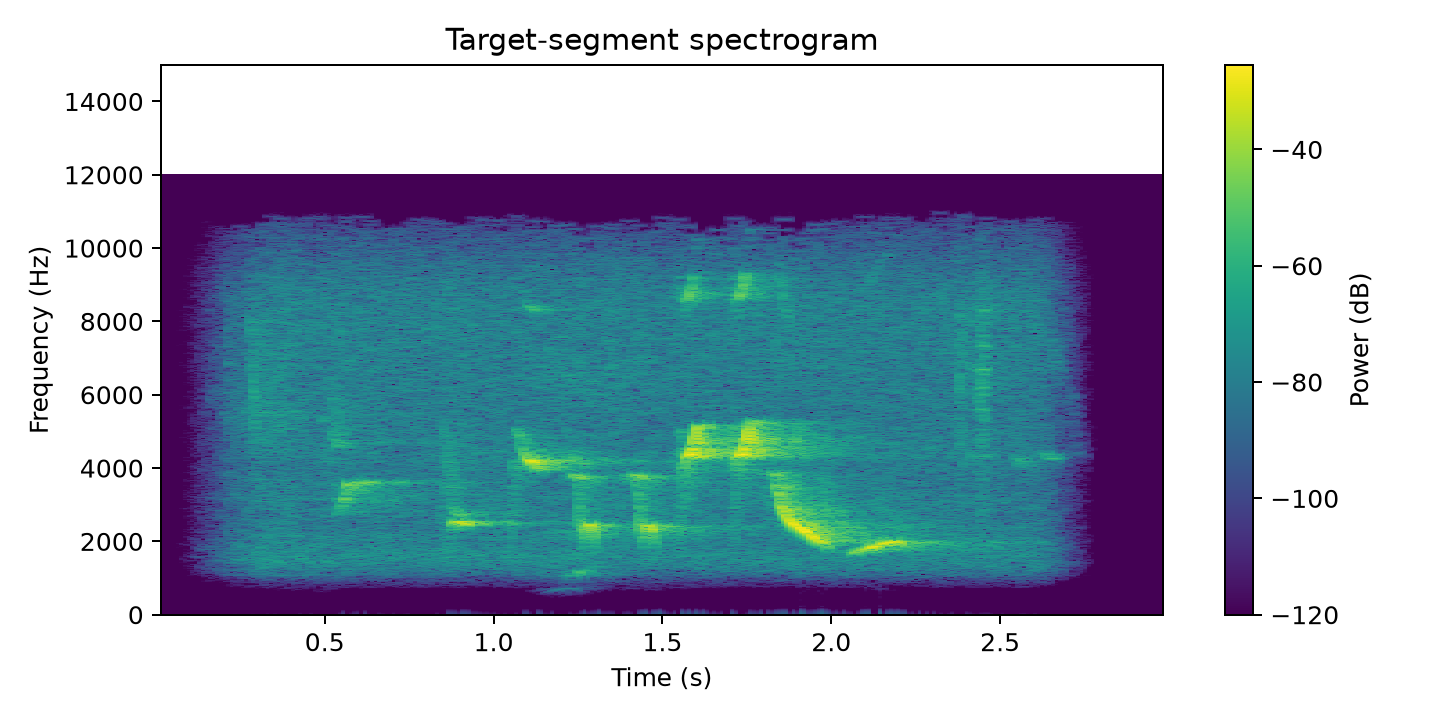

In [13]:
report.show(Artifact.SPECTROGRAM)